# 🏏 IPL Data Analysis

## Overview

An exploratory data analysis of Indian Premier League match and ball-by-ball data, using Pandas and Matplotlib to uncover patterns in team performance, player performance, match outcomes, and other aspects of IPL cricket.


## 1. Setup and Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

matches=pd.read_csv("../data/matches.csv")
deliveries=pd.read_csv("../data/deliveries.csv")

## 2. Data Cleaning

### 2.1 Identifying Inconsistent Team Names

Before analysis, team names are checked for inconsistencies because some IPL teams appear under different names across different seasons.

In [2]:
pd.concat([matches["team1"],matches["team2"]]).value_counts()

Mumbai Indians                 261
Kolkata Knight Riders          251
Royal Challengers Bangalore    240
Chennai Super Kings            238
Rajasthan Royals               221
Kings XI Punjab                190
Sunrisers Hyderabad            182
Delhi Daredevils               161
Delhi Capitals                  91
Deccan Chargers                 75
Punjab Kings                    56
Pune Warriors                   46
Gujarat Titans                  45
Lucknow Super Giants            44
Gujarat Lions                   30
Rising Pune Supergiant          16
Royal Challengers Bengaluru     15
Kochi Tuskers Kerala            14
Rising Pune Supergiants         14
Name: count, dtype: int64

In [3]:
pd.concat([deliveries["batting_team"],deliveries["bowling_team"]]).value_counts()

Mumbai Indians                 62942
Kolkata Knight Riders          59177
Chennai Super Kings            57227
Royal Challengers Bangalore    56563
Rajasthan Royals               52674
Kings XI Punjab                45129
Sunrisers Hyderabad            43560
Delhi Daredevils               37511
Delhi Capitals                 22162
Deccan Chargers                18073
Punjab Kings                   13552
Pune Warriors                  10900
Gujarat Titans                 10795
Lucknow Super Giants           10626
Gujarat Lions                   7111
Rising Pune Supergiant          3828
Royal Challengers Bengaluru     3619
Kochi Tuskers Kerala            3196
Rising Pune Supergiants         3195
Name: count, dtype: int64

### 2.2 Standardizing Team Names

The identified team-name variations are standardized so that the same team is treated as one entity throughout the analysis.

In [4]:
team_mapping = {
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru",
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
    "Rising Pune Supergiant": "Rising Pune Supergiants"
}

In [5]:
matches["team1"] = matches["team1"].replace(team_mapping)
matches["team2"] = matches["team2"].replace(team_mapping)
matches["winner"]=matches["winner"].replace(team_mapping)

deliveries["batting_team"] = deliveries["batting_team"].replace(team_mapping)
deliveries["bowling_team"] = deliveries["bowling_team"].replace(team_mapping)

### 2.3 Verifying Team Names

The standardized team columns are combined and checked to confirm that the team names are consistent across the datasets.

In [6]:
all_teams=pd.concat(

    [matches["team1"],matches["team2"],
     deliveries["batting_team"],deliveries["bowling_team"]

     ]

)
all_teams.value_counts()

Mumbai Indians                 63203
Royal Challengers Bengaluru    60437
Delhi Capitals                 59925
Kolkata Knight Riders          59428
Punjab Kings                   58927
Chennai Super Kings            57465
Rajasthan Royals               52895
Sunrisers Hyderabad            43742
Deccan Chargers                18148
Pune Warriors                  10946
Gujarat Titans                 10840
Lucknow Super Giants           10670
Gujarat Lions                   7141
Rising Pune Supergiants         7053
Kochi Tuskers Kerala            3210
Name: count, dtype: int64

## 3. Team Performance Analysis

### 3.1 Total Matches Played

Calculate the total number of matches played by each team using the `team1` and `team2` columns.

In [7]:
total_matches=pd.concat([matches["team1"],matches["team2"]]).value_counts()
total_matches

Mumbai Indians                 261
Royal Challengers Bengaluru    255
Delhi Capitals                 252
Kolkata Knight Riders          251
Punjab Kings                   246
Chennai Super Kings            238
Rajasthan Royals               221
Sunrisers Hyderabad            182
Deccan Chargers                 75
Pune Warriors                   46
Gujarat Titans                  45
Lucknow Super Giants            44
Gujarat Lions                   30
Rising Pune Supergiants         30
Kochi Tuskers Kerala            14
Name: count, dtype: int64

### 3.2 Total Wins

Calculate the total number of matches won by each team.

In [8]:
total_wins=matches["winner"].value_counts()
total_wins


winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bengaluru    123
Delhi Capitals                 115
Rajasthan Royals               112
Punjab Kings                   112
Sunrisers Hyderabad             88
Deccan Chargers                 29
Gujarat Titans                  28
Lucknow Super Giants            24
Rising Pune Supergiants         15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: count, dtype: int64

### 3.3 Win Percentage

Calculate each team's win percentage based on total matches played and total wins.

In [9]:
win_percentage=total_wins/total_matches*100
win_percentage.round(2)

winner
Chennai Super Kings            57.98
Deccan Chargers                38.67
Delhi Capitals                 45.63
Gujarat Lions                  43.33
Gujarat Titans                 62.22
Kochi Tuskers Kerala           42.86
Kolkata Knight Riders          52.19
Lucknow Super Giants           54.55
Mumbai Indians                 55.17
Pune Warriors                  26.09
Punjab Kings                   45.53
Rajasthan Royals               50.68
Rising Pune Supergiants        50.00
Royal Challengers Bengaluru    48.24
Sunrisers Hyderabad            48.35
Name: count, dtype: float64

### 3.4 Wins by Runs

Determine how many matches each team won by runs.

In [10]:
matches_by_runs=matches[matches["result"]=="runs"].groupby("winner").size()
matches_by_runs

winner
Chennai Super Kings            71
Deccan Chargers                18
Delhi Capitals                 46
Gujarat Lions                   1
Gujarat Titans                 11
Kochi Tuskers Kerala            2
Kolkata Knight Riders          54
Lucknow Super Giants           16
Mumbai Indians                 71
Pune Warriors                   6
Punjab Kings                   51
Rajasthan Royals               43
Rising Pune Supergiants         7
Royal Challengers Bengaluru    57
Sunrisers Hyderabad            44
dtype: int64

### 3.5 Wins by Wickets

Determine how many matches each team won by wickets.

In [11]:
matches_by_wickets=matches[matches["result"]=="wickets"].groupby("winner").size()
matches_by_wickets

winner
Chennai Super Kings            67
Deccan Chargers                11
Delhi Capitals                 66
Gujarat Lions                  12
Gujarat Titans                 17
Kochi Tuskers Kerala            4
Kolkata Knight Riders          76
Lucknow Super Giants            8
Mumbai Indians                 71
Pune Warriors                   6
Punjab Kings                   58
Rajasthan Royals               67
Rising Pune Supergiants         8
Royal Challengers Bengaluru    64
Sunrisers Hyderabad            43
dtype: int64

### 3.6 Team Performance Summary

Combine the team-level metrics into a single summary table for comparison.

In [12]:
team_performance=pd.concat([total_matches,total_wins,win_percentage.round(2),matches_by_runs,matches_by_wickets],axis=1)
team_performance.columns = ["total_matches", "total_wins", "win_percentage","matches_by_runs","matches_by_wickets"]
team_performance

,total_matches,total_wins,win_percentage,matches_by_runs,matches_by_wickets
Mumbai Indians,261,144,55.17,71,71
Royal Challengers Bengaluru,255,123,48.24,57,64
Delhi Capitals,252,115,45.63,46,66
Kolkata Knight Riders,251,131,52.19,54,76
Punjab Kings,246,112,45.53,51,58
Chennai Super Kings,238,138,57.98,71,67
Rajasthan Royals,221,112,50.68,43,67
Sunrisers Hyderabad,182,88,48.35,44,43
Deccan Chargers,75,29,38.67,18,11
Pune Warriors,46,12,26.09,6,6


## 4. Player Performance Analysis

### 4.1 Top 10 Run Scorers

Identify the batters with the highest total runs across the IPL dataset.

In [13]:
top10_scorers=deliveries.groupby("batter")["batsman_runs"].sum().sort_values(ascending=False).head(10)
top10_scorers

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64

### 4.2 Top 10 Wicket Takers

Identify the bowlers with the highest total number of wickets.

In [14]:
top10_wicket_takers=deliveries.groupby("bowler")["is_wicket"].sum().sort_values(ascending=False).head(10)
top10_wicket_takers

bowler
YS Chahal     213
DJ Bravo      207
PP Chawla     201
SP Narine     200
R Ashwin      198
B Kumar       195
SL Malinga    188
A Mishra      183
JJ Bumrah     182
RA Jadeja     169
Name: is_wicket, dtype: int64

### 4.3 Top  10 Six Hitters

Identify the batters who have hit the most sixes.

In [15]:
top10_sixers= deliveries[deliveries["batsman_runs"]==6].groupby("batter").size().sort_values(ascending=False).head(10)
top10_sixers

batter
CH Gayle          359
RG Sharma         281
V Kohli           273
AB de Villiers    253
MS Dhoni          252
DA Warner         236
KA Pollard        224
AD Russell        209
SV Samson         206
SK Raina          204
dtype: int64

### 4.4 total balls faced by each batter

calculating the balls faced by each batter

In [16]:
total_balls_faced = (
    deliveries[deliveries["extras_type"] != "wides"]
    .groupby("batter")
    .size().sort_values(ascending=False)
)
total_balls_faced

batter
V Kohli         6069
S Dhawan        5326
RG Sharma       5057
DA Warner       4702
SK Raina        4046
                ... 
S Lamichhane       1
Mayank Dagar       1
Sunny Gupta        1
SZ Mulani          1
U Kaul             1
Length: 673, dtype: int64

### 4.5 Top 10 Strike Rates
finding which batters have the highest strike rate

In [17]:
top10_strike_rate=deliveries.groupby("batter")["batsman_runs"].sum().sort_values(ascending=False)/total_balls_faced*100
top10_strike_rate=top10_strike_rate[total_balls_faced>=500].sort_values(ascending=False).head(10)

top10_strike_rate


batter
AD Russell         174.841883
H Klaasen          168.305085
SP Narine          165.837838
LS Livingstone     162.456747
N Pooran           161.996337
RM Patidar         158.846918
GJ Maxwell         156.698700
V Sehwag           155.441595
Abhishek Sharma    155.242390
SO Hetmyer         153.078818
dtype: float64


### 4.6 Total Runs Scored

finding out the total runs

In [18]:
total_runs_scored=deliveries.groupby("batter")["batsman_runs"].sum().sort_values(ascending=False)
total_runs_scored

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
                  ... 
JL Denly             0
ND Doshi             0
C Nanda              0
Yash Dayal           0
V Pratap Singh       0
Name: batsman_runs, Length: 673, dtype: int64

### 4.7 Total Matches Played

calculating the total number of matches

In [19]:
total_matches=deliveries.groupby("batter")["match_id"].nunique().sort_values(ascending=False).head(30)
total_matches

batter
RG Sharma         251
V Kohli           244
KD Karthik        233
MS Dhoni          228
S Dhawan          221
SK Raina          200
RV Uthappa        197
AT Rayudu         185
DA Warner         184
RA Jadeja         180
AM Rahane         171
AB de Villiers    170
KA Pollard        168
SV Samson         162
MK Pandey         158
YK Pathan         153
G Gambhir         151
WP Saha           143
CH Gayle          141
SR Watson         141
F du Plessis      138
PA Patel          136
SA Yadav          135
GJ Maxwell        128
HH Pandya         128
Yuvraj Singh      126
DA Miller         123
KL Rahul          122
MA Agarwal        121
SS Iyer           114
Name: match_id, dtype: int64


### 4.8 Average Runs per Match

finding out the highest avergae by a batter

In [20]:
highest_avg=total_runs_scored/total_matches
highest_avg=highest_avg[total_matches>10].sort_values(ascending=False)
highest_avg

IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).

### 4.9 Total Innings
finding out the total innings played by a player

In [ ]:
total_innings=deliveries[
(deliveries["inning"]==1) | (deliveries["inning"]==2)].groupby(["batter","match_id"])["inning"].nunique()
total_innings = total_innings.groupby("batter").sum().sort_values(ascending=False).head(30)
total_innings

batter
RG Sharma         251
V Kohli           244
KD Karthik        233
MS Dhoni          228
S Dhawan          221
SK Raina          200
RV Uthappa        197
AT Rayudu         185
DA Warner         184
RA Jadeja         180
AM Rahane         171
AB de Villiers    170
KA Pollard        168
SV Samson         162
MK Pandey         158
YK Pathan         153
G Gambhir         151
WP Saha           143
CH Gayle          141
SR Watson         141
F du Plessis      138
PA Patel          136
SA Yadav          135
GJ Maxwell        128
HH Pandya         128
Yuvraj Singh      126
DA Miller         123
KL Rahul          122
MA Agarwal        121
SS Iyer           114
Name: inning, dtype: int64


### 4.10 Total Sixes
finding out the total sixes hit by each batter


In [ ]:
total_sixes=deliveries[deliveries["batsman_runs"]==6].groupby("batter").size().sort_values(ascending=False)
total_sixes

batter
CH Gayle          359
RG Sharma         281
V Kohli           273
AB de Villiers    253
MS Dhoni          252
                 ... 
AJ Hosein           1
TS Mills            1
AN Ahmed            1
TU Deshpande        1
VH Zol              1
Length: 451, dtype: int64

### 4.11 Average Sixes per Match

finding out who hits more sixes in a match

In [ ]:
high_avg_sixes=total_sixes/total_matches
high_avg_sixes=high_avg_sixes.dropna()
high_avg_sixes=high_avg_sixes[total_matches>10].sort_values(ascending=False)
high_avg_sixes

batter
CH Gayle          2.546099
KL Rahul          1.532787
AB de Villiers    1.488235
SR Watson         1.347518
KA Pollard        1.333333
DA Warner         1.282609
SV Samson         1.271605
GJ Maxwell        1.250000
F du Plessis      1.202899
Yuvraj Singh      1.182540
RG Sharma         1.119522
V Kohli           1.118852
MS Dhoni          1.105263
DA Miller         1.089431
HH Pandya         1.070312
YK Pathan         1.052288
SK Raina          1.020000
SS Iyer           0.991228
SA Yadav          0.962963
AT Rayudu         0.935135
RV Uthappa        0.923858
MA Agarwal        0.809917
MK Pandey         0.702532
S Dhawan          0.692308
KD Karthik        0.690987
WP Saha           0.608392
AM Rahane         0.602339
RA Jadeja         0.594444
G Gambhir         0.390728
PA Patel          0.360294
dtype: float64


### 4.12 Highest Single-Match Score


calculating the highest runs scored by a batter

In [ ]:
highest_runs=deliveries.groupby(["batter","match_id"])["batsman_runs"].sum().sort_values(ascending=False)
highest_runs=highest_runs.groupby("batter").max().sort_values(ascending=False)
highest_runs

batter
CH Gayle          175
BB McCullum       158
Q de Kock         140
AB de Villiers    133
KL Rahul          132
                 ... 
ND Doshi            0
IC Pandey           0
Mayank Dagar        0
Yash Dayal          0
K Yadav             0
Name: batsman_runs, Length: 673, dtype: int64


### 4.13 Runs by a Batter in Each Match


In [ ]:
runs_per_match=deliveries.groupby(["batter","match_id"])["batsman_runs"].sum().sort_values(ascending=False)
runs_per_match


batter          match_id
CH Gayle        598027      175
BB McCullum     335982      158
Q de Kock       1304112     140
AB de Villiers  829795      133
KL Rahul        1216510     132
                           ... 
TA Boult        1216492       0
                1426311       0
                1426269       0
                1359516       0
                1359497       0
Name: batsman_runs, Length: 16515, dtype: int64

### 4.14 Most 50+ Scores
finding out who has hit the most 50s


In [ ]:
most50s=runs_per_match[runs_per_match>=50].groupby("batter").size().sort_values(ascending=False)
most50s

batter
DA Warner         66
V Kohli           64
S Dhawan          53
RG Sharma         45
AB de Villiers    44
                  ..
Shahbaz Ahmed      1
VVS Laxman         1
UBT Chand          1
Vivrant Sharma     1
W Jaffer           1
Name: batsman_runs, Length: 207, dtype: int64

## 5. Bowling Performance Analysis

### 5.1 Top 10 Wicket Takers

Identify the bowlers who have taken the most wickets across the IPL.

Only wickets credited to the bowler are counted. Dismissals such as run outs, retired hurt, and obstructing the field are excluded.

In [ ]:
bowler_wickets = deliveries[
    (deliveries["is_wicket"] == 1) &
    (~deliveries["dismissal_kind"].isin([
        "run out",
        "retired hurt",
        "obstructing the field"
    ]))
].groupby("bowler")["is_wicket"].sum().sort_values(ascending=False)

top10_wicket_takers = bowler_wickets.head(10)

top10_wicket_takers

bowler
YS Chahal     205
PP Chawla     192
DJ Bravo      183
B Kumar       181
R Ashwin      180
SP Narine     180
A Mishra      174
SL Malinga    170
JJ Bumrah     168
RA Jadeja     160
Name: is_wicket, dtype: int64

### 5.2 Runs Conceded by Bowlers

Calculate the total runs conceded by each bowler.

Byes and leg-byes are excluded because these runs are not charged to the bowler.

In [ ]:
bowler_runs_conceded = deliveries[
    ~deliveries["extras_type"].isin(["byes", "legbyes"])
].groupby("bowler")["total_runs"].sum().sort_values(ascending=False)

bowler_runs_conceded.head(10)

bowler
R Ashwin           5369
PP Chawla          5108
B Kumar            4929
RA Jadeja          4864
YS Chahal          4602
SP Narine          4582
DJ Bravo           4360
UT Yadav           4331
A Mishra           4145
Harbhajan Singh    4030
Name: total_runs, dtype: int64

### 5.3 Total Balls Bowled

Calculate the total number of legal deliveries bowled by each bowler.

Wides and no-balls are excluded because they do not count as legal deliveries in cricket.

In [ ]:
legal_deliveries = deliveries[
    ~deliveries["extras_type"].isin(["wides", "noballs"])
]

balls_bowled = (
    legal_deliveries.groupby("bowler")
    .size()
    .sort_values(ascending=False)
)

balls_bowled.head(10)

bowler
R Ashwin           4524
SP Narine          4081
B Kumar            3910
PP Chawla          3850
RA Jadeja          3829
YS Chahal          3521
Harbhajan Singh    3416
A Mishra           3371
DJ Bravo           3120
AR Patel           3105
dtype: int64

### 5.4 Bowling Economy Rate

Calculate the economy rate of each bowler, which measures the average number of runs conceded per over.

Only bowlers who have bowled at least 500 legal deliveries are included to avoid rankings being dominated by players with very few deliveries.

In [ ]:
overs_bowled = balls_bowled / 6

economy_rate = (
    bowler_runs_conceded / overs_bowled
).dropna()

economy_rate = economy_rate[balls_bowled >= 500].sort_values()

economy_rate.head(10)

bowler
A Kumble           6.578238
M Muralitharan     6.698953
SP Narine          6.736584
DL Vettori         6.787645
Rashid Khan        6.825209
J Botha            6.916427
DW Steyn           6.937672
R Sharma           7.021552
MM Ali             7.068602
Harbhajan Singh    7.078454
dtype: float64

### 5.5 Bowling Strike Rate

Calculate the bowling strike rate for each bowler.

Bowling strike rate represents the average number of legal deliveries a bowler needs to take one wicket.

Only bowlers with at least 500 legal deliveries are included.

In [ ]:
bowling_strike_rate = (
    balls_bowled / bowler_wickets
).dropna()

bowling_strike_rate = bowling_strike_rate[
    balls_bowled >= 500
].sort_values()

bowling_strike_rate.head(10)

bowler
AD Russell      14.756522
MR Marsh        15.135135
K Rabada        15.241667
DE Bollinger    15.567568
PWH de Silva    15.771429
HV Patel        16.014815
Imran Tahir     16.048780
MA Starc        16.294118
AJ Tye          16.309524
SL Malinga      16.635294
dtype: float64

### 5.6 Bowling Average

Calculate the bowling average for each bowler.

Bowling average represents the average number of runs conceded by a bowler for each wicket taken.

Only bowlers with at least 500 legal deliveries are included.

In [ ]:
bowling_average = (
    bowler_runs_conceded / bowler_wickets
).dropna()

bowling_average = bowling_average[
    balls_bowled >= 500
].sort_values()

bowling_average.head(10)

bowler
DE Bollinger    18.729730
SL Malinga      19.829412
Imran Tahir     20.768293
PWH de Silva    21.371429
K Rabada        21.475000
MR Marsh        21.486486
Rashid Khan     21.926174
JJ Bumrah       22.279762
MA Starc        22.294118
YS Chahal       22.448780
dtype: float64

### 5.7 Dot Balls

Calculate the total number of dot balls bowled by each bowler.

A dot ball is a legal delivery on which the batting team scores no runs.

In [ ]:
dot_balls = deliveries[
    (deliveries["total_runs"] == 0) &
    (~deliveries["extras_type"].isin(["wides", "noballs"]))
].groupby("bowler").size().sort_values(ascending=False)

top10_dot_bowlers = dot_balls.head(10)

top10_dot_bowlers

bowler
B Kumar            1632
SP Narine          1569
R Ashwin           1552
PP Chawla          1325
Harbhajan Singh    1263
JJ Bumrah          1228
RA Jadeja          1216
YS Chahal          1194
UT Yadav           1186
A Mishra           1185
dtype: int64

### 5.8 Four-Wicket and Five-Wicket Hauls

Identify bowlers who have taken at least four wickets in a single match.

The analysis first calculates wickets taken by each bowler in each match, then counts their four-wicket and five-wicket hauls.

In [ ]:
wickets_per_match = deliveries[
    (deliveries["is_wicket"] == 1) &
    (~deliveries["dismissal_kind"].isin([
        "run out",
        "retired hurt",
        "obstructing the field"
    ]))
].groupby(["bowler", "match_id"])["is_wicket"].sum()

wickets_per_match

bowler          match_id
A Ashish Reddy  548341      2
                548346      1
                548348      1
                548352      1
                548356      1
                           ..
Z Khan          1082595     2
                1082599     3
                1082608     2
                1082642     2
                1082646     1
Name: is_wicket, Length: 7412, dtype: int64

In [ ]:
four_wicket_hauls = (
    wickets_per_match[wickets_per_match >= 4]
    .groupby("bowler")
    .size()
    .sort_values(ascending=False)
)

four_wicket_hauls.head(10)

bowler
SP Narine        8
K Rabada         7
SL Malinga       7
YS Chahal        7
JJ Bumrah        5
A Mishra         5
L Balaji         4
MM Sharma        4
Kuldeep Yadav    4
AJ Tye           4
Name: is_wicket, dtype: int64

In [ ]:
five_wicket_hauls = (
    wickets_per_match[wickets_per_match >= 5]
    .groupby("bowler")
    .size()
    .sort_values(ascending=False)
)

five_wicket_hauls.head(10)

bowler
JJ Bumrah      3
JD Unadkat     2
JP Faulkner    2
B Kumar        2
AD Russell     1
AJ Tye         1
A Kumble       1
A Mishra       1
AS Rajpoot     1
AS Joseph      1
Name: is_wicket, dtype: int64

### 5.9 Best Bowling Performance

Identify the best individual bowling performances based on the highest number of wickets taken by a bowler in a single match.

In [ ]:
best_bowling_figures = (
    wickets_per_match
    .groupby("bowler")
    .max()
    .sort_values(ascending=False)
)

best_bowling_figures.head(10)

bowler
Sohail Tanvir     6
AS Joseph         6
A Zampa           6
AD Russell        5
AD Mascarenhas    5
AS Rajpoot        5
Akash Madhwal     5
AJ Tye            5
B Kumar           5
Arshdeep Singh    5
Name: is_wicket, dtype: int64

## 6. Match Analysis

### 6.1 Toss Winner vs Match Winner

Analyze how often the team that won the toss also won the match.

In [ ]:
toss_and_match_wins = (
    matches["toss_winner"] == matches["winner"]
)

toss_and_match_wins.value_counts()

False    674
True     421
Name: count, dtype: int64

In [ ]:
toss_win_percentage = (
    toss_and_match_wins.mean() * 100
)

round(toss_win_percentage, 2)

np.float64(38.45)

### 6.2 Toss Decision

Analyze the decisions teams made after winning the toss, comparing the number of times teams chose to bat first versus field first.

In [ ]:
toss_decisions = matches["toss_decision"].value_counts()

toss_decisions

toss_decision
field    704
bat      391
Name: count, dtype: int64

### 6.3 Toss Decision by Season

Analyze how teams' toss decisions changed across IPL seasons by comparing the number of times teams chose to bat first versus field first.

In [ ]:
toss_decision_by_season = (
    matches.groupby(["season", "toss_decision"])
    .size()
    .unstack(fill_value=0)
)

toss_decision_by_season

toss_decision,bat,field
season,,
2007/08,26,32
2009,35,22
2009/10,39,21
2011,25,48
2012,37,37
2013,45,31
2014,19,41
2015,25,34
2016,11,49


### 6.4 Toss Decision vs Match Outcome

Analyze the relationship between the toss decision and match outcome by comparing how often teams that chose to bat or field after winning the toss also won the match.

In [ ]:
matches["toss_winner_won"] = matches["toss_winner"] == matches["winner"]

toss_outcome = (
    matches.groupby("toss_decision")["toss_winner_won"]
    .agg(["count", "sum", "mean"])
)

toss_outcome["win_percentage"] = toss_outcome["mean"] * 100

toss_outcome


,count,sum,mean,win_percentage
toss_decision,,,,
bat,391,144,0.368286,36.828645
field,704,277,0.393466,39.346591


### 6.5 Batting First vs Chasing

Analyze match outcomes based on whether a team won while batting first or while chasing a target.

In [ ]:
result_type = matches["result"].value_counts()

result_type

result
wickets      578
runs         498
tie           14
no result      5
Name: count, dtype: int64

In [ ]:
result_percentage = (
    result_type / result_type.sum() * 100
).round(2)

result_percentage

result
wickets      52.79
runs         45.48
tie           1.28
no result     0.46
Name: count, dtype: float64

### 6.6 Win Margins

Analyze the margins by which teams won their matches, including wins by runs and wins by wickets.

In [ ]:
wins_by_runs = (
    matches[matches["result"] == "runs"]["result_margin"]
    .describe()
)

wins_by_wickets = (
    matches[matches["result"] == "wickets"]["result_margin"]
    .describe()
)

wins_by_runs, wins_by_wickets

(count    498.000000
 mean      30.104418
 std       26.739844
 min        1.000000
 25%       11.000000
 50%       22.000000
 75%       41.000000
 max      146.000000
 Name: result_margin, dtype: float64,
 count    578.000000
 mean       6.192042
 std        1.845733
 min        1.000000
 25%        5.000000
 50%        6.000000
 75%        7.000000
 max       10.000000
 Name: result_margin, dtype: float64)

### 6.7 Close Matches

Identify closely contested matches by examining small winning margins in matches decided by runs or wickets.

In [ ]:
close_run_wins = matches[
    (matches["result"] == "runs") &
    (matches["result_margin"] <= 5)
]

close_wicket_wins = matches[
    (matches["result"] == "wickets") &
    (matches["result_margin"] <= 2)
]

print("Close wins by runs:", len(close_run_wins))
print("Close wins by wickets:", len(close_wicket_wins))

Close wins by runs: 60
Close wins by wickets: 14


### 6.8 Super Over Matches

Analyze how many IPL matches were decided by a Super Over.

In [23]:
super_over_matches = matches[matches["super_over"] == "Y"]

len(super_over_matches)

14

In [24]:
super_over_by_season = (
    super_over_matches["season"]
    .value_counts()
    .sort_index()
)

super_over_by_season

season
2009       1
2009/10    1
2013       2
2014       1
2015       1
2017       1
2019       2
2020/21    4
2021       1
Name: count, dtype: int64

### 6.9 D/L Method Matches

Analyze matches that were affected by the Duckworth–Lewis method and examine how frequently they occurred across IPL seasons.

In [27]:
dl_matches = matches[matches["method"] == "D/L"]

len(dl_matches)

21

In [28]:
dl_by_season = (
    dl_matches["season"]
    .value_counts()
    .sort_index()
)

dl_by_season

season
2007/08    2
2009       3
2011       3
2014       1
2015       2
2016       4
2017       1
2018       3
2023       2
Name: count, dtype: int64

### 6.10 Match Types

Analyze the distribution of IPL matches across different match types.

In [ ]:
match_types = matches.groupby("season")["match_type"].value_counts()

match_types

season   match_type 
2007/08  League         55
         Semi Final      2
         Final           1
2009     League         54
         Semi Final      2
                        ..
2024     League         67
         Qualifier 2     1
         Qualifier 1     1
         Eliminator      1
         Final           1
Name: count, Length: 80, dtype: int64

In [ ]:
match_type_by_season = (
    matches.groupby(["season", "match_type"])
    .size()
    .unstack(fill_value=0)
)

match_type_by_season

match_type,3rd Place Play-Off,Elimination Final,Eliminator,Final,League,Qualifier 1,Qualifier 2,Semi Final
season,,,,,,,,
2007/08,0,0,0,1,55,0,0,2
2009,0,0,0,1,54,0,0,2
2009/10,1,0,0,1,56,0,0,2
2011,0,1,0,1,69,1,1,0
2012,0,1,0,1,70,1,1,0
2013,0,0,1,1,72,1,1,0
2014,0,0,1,1,56,1,1,0
2015,0,0,1,1,55,1,1,0
2016,0,1,0,1,56,1,1,0


## 7. Venue & Location Analysis


### 7.1 Most Used Venues

Analyze which venues hosted the highest number of IPL matches.

In [31]:
venue_matches = matches["venue"].value_counts()

top10_venues = venue_matches.head(10)

top10_venues


venue
Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         65
Feroz Shah Kotla                              60
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Stadium, Chepauk               48
Sawai Mansingh Stadium                        47
Dubai International Cricket Stadium           46
Wankhede Stadium, Mumbai                      45
Punjab Cricket Association Stadium, Mohali    35
Name: count, dtype: int64

### 7.2 Matches by City

Analyze the number of IPL matches hosted by each city and identify the cities with the highest match counts.

In [34]:
matches_by_city = matches["city"].value_counts()

top10_cities = matches_by_city.head(10)

top10_cities

city
Mumbai        173
Kolkata        93
Delhi          90
Chennai        85
Hyderabad      77
Bangalore      65
Chandigarh     61
Jaipur         57
Pune           51
Abu Dhabi      37
Name: count, dtype: int64

### 7.3 Venue Match Counts by Season

Examine the number of matches hosted at each venue across IPL seasons to understand how venue usage has changed over time.

In [ ]:
venue_by_season = (
  matches.groupby(["season", "venue"]).size()
    .unstack(fill_value=0)
)

venue_by_season

venue,Arun Jaitley Stadium,"Arun Jaitley Stadium, Delhi",Barabati Stadium,"Barsapara Cricket Stadium, Guwahati","Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow",Brabourne Stadium,"Brabourne Stadium, Mumbai",Buffalo Park,De Beers Diamond Oval,Dr DY Patil Sports Academy,...,Shaheed Veer Narayan Singh International Stadium,Sharjah Cricket Stadium,Sheikh Zayed Stadium,St George's Park,Subrata Roy Sahara Stadium,SuperSport Park,"Vidarbha Cricket Association Stadium, Jamtha",Wankhede Stadium,"Wankhede Stadium, Mumbai","Zayed Cricket Stadium, Abu Dhabi"
season,,,,,,,,,,,,,,,,,,,,,
2007/08,0,0,0,0,0,0,0,0,0,4,...,0,0,0,0,0,0,0,6,0,0
2009,0,0,0,0,0,0,0,3,3,0,...,0,0,0,7,0,12,0,0,0,0
2009/10,0,0,2,0,0,6,1,0,0,6,...,0,0,0,0,0,0,3,0,0,0
2011,0,0,0,0,0,0,0,0,0,7,...,0,0,0,0,0,0,0,9,0,0
2012,0,0,2,0,0,0,0,0,0,0,...,0,0,0,0,9,0,0,8,0,0
2013,0,0,0,0,0,0,0,0,0,0,...,2,0,0,0,7,0,0,8,0,0
2014,0,0,3,0,0,1,0,0,0,0,...,0,6,7,0,0,0,0,6,0,0
2015,0,0,0,0,0,3,0,0,0,0,...,2,0,0,0,0,0,0,8,0,0
2016,0,0,0,0,0,0,0,0,0,0,...,2,0,0,0,0,0,0,4,0,0


### 7.4 Most Frequently Used Venue in Each Season

Identify the venue that hosted the highest number of IPL matches in each season. This helps analyze how venue usage varied across different IPL seasons.

In [ ]:
venue_by_season = (
    matches.groupby(["season", "venue"])
    .size()
    .reset_index(name="match_count")
)

most_used_venue_each_season = (
    venue_by_season
    .sort_values(
        ["season", "match_count"],
        ascending=[True, False]
    )
    .groupby("season")
    .head(1)
)

most_used_venue_each_season

,season,venue,match_count
1,2007/08,Eden Gardens,7
11,2009,Kingsmead,15
21,2009/10,Eden Gardens,7
36,2011,"MA Chidambaram Stadium, Chepauk",9
48,2012,"MA Chidambaram Stadium, Chepauk",10
54,2013,Eden Gardens,8
69,2014,Dubai International Cricket Stadium,7
92,2015,Wankhede Stadium,8
97,2016,M Chinnaswamy Stadium,9
112,2017,"Rajiv Gandhi International Stadium, Uppal",8


### 7.5 Average Winning Margin by Venue

Analyze the average winning margin at each venue, separately for matches won by runs and matches won by wickets.

In [ ]:
average_margin_by_venue = (
    matches[matches["result"].isin(["runs","wickets"])].groupby(["venue","result"])["result_margin"]
    .mean()
    .unstack(fill_value=0)
)

average_margin_by_venue

result,runs,wickets
venue,,
Arun Jaitley Stadium,23.428571,5.833333
"Arun Jaitley Stadium, Delhi",32.444444,5.857143
Barabati Stadium,18.250000,6.666667
"Barsapara Cricket Stadium, Guwahati",31.000000,5.000000
"Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow",33.142857,5.333333
Brabourne Stadium,22.666667,6.250000
"Brabourne Stadium, Mumbai",28.375000,6.333333
Buffalo Park,43.500000,7.000000
De Beers Diamond Oval,53.000000,5.000000


### 7.6 Venues Used Across the Most Seasons

Identify the venues that have hosted IPL matches across the highest number of different seasons.

In [ ]:
venue_seasons = (
    matches.groupby("venue")["season"]
    .nunique()
    .sort_values(ascending=False)
)

top10_venue_seasons = venue_seasons.head(10)

top10_venue_seasons

venue
Eden Gardens                                           11
Wankhede Stadium                                       10
M Chinnaswamy Stadium                                   9
Feroz Shah Kotla                                        9
Rajiv Gandhi International Stadium, Uppal               8
Punjab Cricket Association Stadium, Mohali              7
Sawai Mansingh Stadium                                  7
MA Chidambaram Stadium, Chepauk                         6
Maharashtra Cricket Association Stadium                 5
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium     4
Name: season, dtype: int64

### 7.7 Matches Hosted by City and Season

Analyze how the number of IPL matches hosted by each city has changed across seasons.

In [ ]:
matches_by_city_season = (
    matches.groupby(["season", "city"])
    .size()
    .unstack(fill_value=0)
)

matches_by_city_season

city,Abu Dhabi,Ahmedabad,Bangalore,Bengaluru,Bloemfontein,Cape Town,Centurion,Chandigarh,Chennai,Cuttack,...,Mumbai,Nagpur,Navi Mumbai,Port Elizabeth,Pune,Raipur,Rajkot,Ranchi,Sharjah,Visakhapatnam
season,,,,,,,,,,,,,,,,,,,,,
2007/08,0,0,7,0,0,0,0,7,7,0,...,10,0,0,0,0,0,0,0,0,0
2009,0,0,0,0,2,7,12,0,0,0,...,0,0,0,7,0,0,0,0,0,0
2009/10,0,4,7,0,0,0,0,5,7,2,...,13,3,0,0,0,0,0,0,0,0
2011,0,0,6,0,0,0,0,4,9,0,...,16,0,0,0,0,0,0,0,0,0
2012,0,0,8,0,0,0,0,6,10,2,...,8,0,0,0,9,0,0,0,0,2
2013,0,0,8,0,0,0,0,6,8,0,...,8,0,0,0,8,2,0,2,0,0
2014,7,4,6,0,0,0,0,3,0,3,...,7,0,0,0,0,0,0,4,0,0
2015,0,4,7,0,0,0,0,4,7,0,...,11,0,0,0,4,2,0,1,0,3
2016,0,0,9,0,0,0,0,7,0,0,...,4,0,0,0,4,2,5,0,0,6


### 7.8 Top Venues by Match Share

Calculate the percentage of total IPL matches hosted by the most frequently used venues.

In [ ]:
venue_match_counts = matches["venue"].value_counts()

venue_share = (
    venue_match_counts
    .head(10)
    .to_frame("match_count")
)

venue_share["match_percentage"] = (
    venue_share["match_count"] / len(matches) * 100
)

venue_share

,match_count,match_percentage
venue,,
Eden Gardens,77,7.031963
Wankhede Stadium,73,6.666667
M Chinnaswamy Stadium,65,5.936073
Feroz Shah Kotla,60,5.479452
"Rajiv Gandhi International Stadium, Uppal",49,4.474886
"MA Chidambaram Stadium, Chepauk",48,4.383562
Sawai Mansingh Stadium,47,4.292237
Dubai International Cricket Stadium,46,4.200913
"Wankhede Stadium, Mumbai",45,4.109589


## 8. Batting & Scoring Analysis

### 8.1 Highest-Scoring Innings

Identify the highest team innings scores in IPL history.

In [45]:
completed_matches = matches[
    matches["winner"].notna() &
    matches["method"].isna()
]["id"]

innings_scores = (
    deliveries[
        deliveries["inning"].isin([1, 2]) &
        deliveries["match_id"].isin(completed_matches)
    ]
    .groupby(["match_id", "inning", "batting_team"])["total_runs"]
    .sum()
    .reset_index(name="total_runs")
)

highest_scoring_innings = (
    innings_scores
    .sort_values("total_runs", ascending=False)
    .head(10)
)

highest_scoring_innings

,match_id,inning,batting_team,total_runs
2054,1426268,1,Sunrisers Hyderabad,287
2010,1422126,1,Sunrisers Hyderabad,277
2026,1422134,1,Kolkata Knight Riders,272
2064,1426273,1,Sunrisers Hyderabad,266
684,598027,1,Royal Challengers Bengaluru,263
2079,1426280,2,Punjab Kings,262
2055,1426268,2,Royal Challengers Bengaluru,262
2078,1426280,1,Kolkata Knight Riders,261
2080,1426281,1,Delhi Capitals,257
1926,1359512,1,Lucknow Super Giants,257


### 8.2 Lowest-Scoring Innings

Identify the lowest team innings scores in IPL history.

In [46]:
lowest_scoring_innings = (
    innings_scores
    .sort_values("total_runs", ascending=True)
    .head(10)
)
lowest_scoring_innings


,match_id,inning,batting_team,total_runs
1171,1082617,2,Royal Challengers Bengaluru,49
115,392182,2,Rajasthan Royals,58
1969,1359534,2,Rajasthan Royals,59
1205,1082635,2,Delhi Capitals,66
78,336021,1,Kolkata Knight Riders,67
1186,1082626,1,Delhi Capitals,67
1776,1304082,1,Royal Challengers Bengaluru,68
79,336021,2,Mumbai Indians,68
1187,1082626,2,Punjab Kings,68
1348,1175356,1,Royal Challengers Bengaluru,70


### 8.3 Average Score by Innings

Compare the average total runs scored in the first and second innings of IPL matches.

In [47]:
average_score_by_innings = (
    innings_scores
    .groupby("inning")["total_runs"]
    .mean()
)

average_score_by_innings

inning
1    166.057998
2    153.518241
Name: total_runs, dtype: float64

### 8.4 Average Team Score by Season

Analyze how the average innings score has changed across IPL seasons.

In [48]:
innings_scores_with_season = innings_scores.merge(
    matches[["id", "season"]],
    left_on="match_id",
    right_on="id"
)
average_score_by_season = (
    innings_scores_with_season
    .groupby("season")["total_runs"]
    .mean()
)

average_score_by_season

season
2007/08    156.437500
2009       144.092593
2009/10    157.200000
2011       148.282609
2012       151.709459
2013       148.296053
2014       158.661017
2015       158.618182
2016       160.294643
2017       160.284483
2018       166.921053
2019       163.533898
2020/21    161.266667
2021       155.183333
2022       164.831081
2023       174.936620
2024       182.894366
Name: total_runs, dtype: float64

### 8.5 Teams with the Highest Average Innings Score

Identify the teams with the highest average runs scored per innings.

In [ ]:
average_team_score = (
    innings_scores
    .groupby("batting_team")["total_runs"]
    .mean()
    .sort_values(ascending=False)
)

average_team_score

batting_team
Lucknow Super Giants           171.744186
Gujarat Titans                 171.431818
Chennai Super Kings            163.637931
Gujarat Lions                  161.866667
Punjab Kings                   161.447699
Mumbai Indians                 161.429119
Sunrisers Hyderabad            160.638418
Royal Challengers Bengaluru    160.313253
Kolkata Knight Riders          158.533058
Rajasthan Royals               158.396313
Rising Pune Supergiants        157.777778
Delhi Capitals                 156.659836
Deccan Chargers                152.840000
Pune Warriors                  141.288889
Kochi Tuskers Kerala           135.846154
Name: total_runs, dtype: float64

### 8.6 Teams with the Most 200+ Innings

Identify the teams that have scored 200 or more runs in an IPL innings most frequently.

In [56]:
teams_200_plus = (
    innings_scores[innings_scores["total_runs"] >= 200]
    .groupby("batting_team")
    .size()
    .sort_values(ascending=False)
)

teams_200_plus

batting_team
Chennai Super Kings            32
Royal Challengers Bengaluru    28
Kolkata Knight Riders          25
Mumbai Indians                 25
Punjab Kings                   24
Rajasthan Royals               21
Sunrisers Hyderabad            21
Delhi Capitals                 16
Lucknow Super Giants            7
Gujarat Titans                  7
Gujarat Lions                   1
Deccan Chargers                 1
dtype: int64

### 8.8 Boundary Contribution — Fours vs Sixes

Analyze the contribution of fours and sixes to overall batting runs in IPL matches.

In [ ]:
boundary_runs = (
    deliveries[deliveries["batsman_runs"].isin([4, 6])]
    .groupby("batsman_runs")
    .agg(
        boundary_count=("batsman_runs", "size"),
        runs=("batsman_runs", "sum")
    )
)

boundary_runs

,boundary_count,runs
batsman_runs,,
4,29850,119400
6,13051,78306


### 8.9 Run Distribution by Over

Analyze the total number of runs scored in each over across IPL matches.

In [ ]:
runs_by_over = (
    deliveries
    .groupby("over")["total_runs"]
    .sum()
    .sort_values(ascending=False)
)

runs_by_over

over
17    19559
18    19076
16    19012
4     18565
5     18528
15    18472
3     18415
14    18149
2     17895
19    17765
13    17634
12    17205
11    17076
10    16779
8     16639
9     16353
1     16163
7     15981
6     14839
0     13651
Name: total_runs, dtype: int64

### 8.10 Powerplay Scoring

Analyze the average number of runs scored by teams during the powerplay across IPL innings.

In [ ]:
powerplay_scores = (
    deliveries[deliveries["over"] < 6]
    .groupby(["match_id", "inning", "batting_team"])["total_runs"]
    .sum()
    .reset_index(name="powerplay_runs")
)

average_powerplay_score = (
    powerplay_scores
    .groupby("batting_team")["powerplay_runs"]
    .mean()
    .sort_values(ascending=False)
)

average_powerplay_score

batting_team
Gujarat Lions                  50.290323
Kochi Tuskers Kerala           48.571429
Gujarat Titans                 48.533333
Sunrisers Hyderabad            48.048387
Rising Pune Supergiants        47.433333
Lucknow Super Giants           47.272727
Delhi Capitals                 47.144531
Punjab Kings                   46.992032
Kolkata Knight Riders          46.827451
Chennai Super Kings            46.180672
Mumbai Indians                 45.958647
Rajasthan Royals               45.856502
Royal Challengers Bengaluru    45.717054
Deccan Chargers                45.560000
Pune Warriors                  42.111111
Name: powerplay_runs, dtype: float64

### 8.11 Death-Over Scoring

Analyze the average number of runs scored by teams during the death overs across IPL innings.

In [ ]:
death_over_scores = (
    deliveries[deliveries["over"] >= 16]
    .groupby(["match_id", "inning", "batting_team"])["total_runs"]
    .sum()
    .reset_index(name="death_over_runs")
)

average_death_over_score = (
    death_over_scores
    .groupby("batting_team")["death_over_runs"]
    .mean()
    .sort_values(ascending=False)
)

average_death_over_score

batting_team
Gujarat Titans                 41.431818
Lucknow Super Giants           40.904762
Chennai Super Kings            39.741228
Mumbai Indians                 39.016260
Royal Challengers Bengaluru    38.746781
Rising Pune Supergiants        38.384615
Sunrisers Hyderabad            36.261628
Punjab Kings                   35.973913
Kolkata Knight Riders          35.950893
Rajasthan Royals               35.517073
Deccan Chargers                35.263889
Delhi Capitals                 34.974359
Gujarat Lions                  32.892857
Pune Warriors                  30.909091
Kochi Tuskers Kerala           30.636364
Name: death_over_runs, dtype: float64

### 8.12 Highest-Scoring Overs

Identify the highest-scoring individual overs in IPL history.

In [ ]:
highest_scoring_overs = (
    deliveries
    .groupby(["match_id", "inning", "batting_team", "over"])["total_runs"]
    .sum()
    .reset_index(name="over_runs")
    .sort_values("over_runs", ascending=False)
    .head(10)
)

highest_scoring_overs

,match_id,inning,batting_team,over,over_runs
8590,501247,2,Royal Challengers Bengaluru,2,37
32116,1254076,1,Chennai Super Kings,19,37
34265,1304060,2,Kolkata Knight Riders,15,35
17590,734047,2,Chennai Super Kings,5,33
5682,419139,1,Kolkata Knight Riders,12,33
40240,1422138,1,Mumbai Indians,19,32
37793,1359505,1,Punjab Kings,15,31
10314,548327,2,Royal Challengers Bengaluru,12,31
37103,1359487,2,Kolkata Knight Riders,19,31
41013,1426278,1,Delhi Capitals,19,31


### 8.13 Highest Team Score by Season

Analyze the highest team innings score recorded in each IPL season.

In [51]:
highest_score_by_season = (
    innings_scores_with_season
    .groupby("season")["total_runs"]
    .max()
)

highest_score_by_season

season
2007/08    240
2009       211
2009/10    246
2011       232
2012       222
2013       263
2014       231
2015       235
2016       248
2017       230
2018       245
2019       232
2020/21    228
2021       235
2022       222
2023       257
2024       287
Name: total_runs, dtype: int64

### 8.14 Team Scoring Consistency

Analyze the consistency of team innings scores using the standard deviation of runs scored per innings.

In [52]:
team_scoring_consistency = (
    innings_scores
    .groupby("batting_team")["total_runs"]
    .agg(["mean", "std"])
    .sort_values("std")
)

team_scoring_consistency

,mean,std
batting_team,,
Gujarat Lions,161.866667,24.868944
Pune Warriors,141.288889,25.318536
Rising Pune Supergiants,157.777778,25.365533
Deccan Chargers,152.840000,25.481864
Chennai Super Kings,163.637931,30.169334
Delhi Capitals,156.659836,30.749671
Mumbai Indians,161.429119,30.760110
Kolkata Knight Riders,158.533058,31.042351
Kochi Tuskers Kerala,135.846154,31.264586


### 8.15 Season Scoring Trend

Analyze how IPL scoring has changed across seasons using average innings score and the highest team innings score.

In [53]:
season_scoring_trend = (
    innings_scores_with_season
    .groupby("season")["total_runs"]
    .agg(
        average_score="mean",
        highest_score="max"
    )
)

season_scoring_trend

,average_score,highest_score
season,,
2007/08,156.437500,240
2009,144.092593,211
2009/10,157.200000,246
2011,148.282609,232
2012,151.709459,222
2013,148.296053,263
2014,158.661017,231
2015,158.618182,235
2016,160.294643,248


## 9. Advanced Team Analysis


## 9.1 Team Performance by Season

Analyze how each team's performance has changed across IPL seasons using matches played, wins, and win percentage.

In [ ]:
team_season_matches = (
    pd.concat([
        matches[["season", "team1"]].rename(columns={"team1": "team"}),
        matches[["season", "team2"]].rename(columns={"team2": "team"})
    ])
    .groupby(["season", "team"])
    .size()
    .reset_index(name="matches_played")
)

team_season_wins = (
    matches
    .dropna(subset=["winner"])
    .groupby(["season", "winner"])
    .size()
    .reset_index(name="wins")
    .rename(columns={"winner": "team"})
)

team_season_performance = (
    team_season_matches
    .merge(
        team_season_wins,
        on=["season", "team"],
        how="left"
    )
)

team_season_performance["wins"] = (
    team_season_performance["wins"].fillna(0)
)

team_season_performance["win_percentage"] = (
    team_season_performance["wins"]
    / team_season_performance["matches_played"]
    * 100
)

team_season_performance

,season,team,matches_played,wins,win_percentage
0,2007/08,Chennai Super Kings,16,9,56.250000
1,2007/08,Deccan Chargers,14,2,14.285714
2,2007/08,Delhi Capitals,14,7,50.000000
3,2007/08,Kolkata Knight Riders,13,6,46.153846
4,2007/08,Mumbai Indians,14,7,50.000000
...,...,...,...,...,...
141,2024,Mumbai Indians,14,4,28.571429
142,2024,Punjab Kings,14,5,35.714286
143,2024,Rajasthan Royals,15,9,60.000000
144,2024,Royal Challengers Bengaluru,15,7,46.666667


### 9.2 Highest Team Win Percentage by Season

Identify the highest team win percentage recorded in each IPL season.

In [ ]:
highest_win_percentage_by_season = (
    team_season_performance
    .groupby("season")["win_percentage"]
    .max()
)

highest_win_percentage_by_season

season
2007/08    81.250000
2009       66.666667
2009/10    68.750000
2011       68.750000
2012       70.588235
2013       68.421053
2014       70.588235
2015       62.500000
2016       64.705882
2017       70.588235
2018       68.750000
2019       68.750000
2020/21    68.750000
2021       68.750000
2022       75.000000
2023       64.705882
2024       78.571429
Name: win_percentage, dtype: float64

### 9.3 Team with the Highest Win Percentage in Each Season

Identify the team with the highest win percentage in each IPL season, along with its matches played and wins.

In [ ]:
top_team_each_season = (
    team_season_performance
    .sort_values(
        ["season", "win_percentage"],
        ascending=[True, False]
    )
    .groupby("season")
    .head(1)
    .reset_index(drop=True)
)

top_team_each_season

,season,team,matches_played,wins,win_percentage
0,2007/08,Rajasthan Royals,16,13,81.250000
1,2009,Delhi Capitals,15,10,66.666667
2,2009/10,Mumbai Indians,16,11,68.750000
3,2011,Chennai Super Kings,16,11,68.750000
4,2012,Kolkata Knight Riders,17,12,70.588235
5,2013,Mumbai Indians,19,13,68.421053
6,2014,Punjab Kings,17,12,70.588235
7,2015,Mumbai Indians,16,10,62.500000
8,2016,Sunrisers Hyderabad,17,11,64.705882
9,2017,Mumbai Indians,17,12,70.588235


### 9.4 Team Wins by Season

Analyze the number of matches won by each team across IPL seasons.

In [ ]:
team_wins_by_season = (
    matches
    .groupby(["season", "winner"])
    .size()
    .reset_index(name="wins")
)

team_wins_by_season

,season,winner,wins
0,2007/08,Chennai Super Kings,9
1,2007/08,Deccan Chargers,2
2,2007/08,Delhi Capitals,7
3,2007/08,Kolkata Knight Riders,6
4,2007/08,Mumbai Indians,7
...,...,...,...
141,2024,Mumbai Indians,4
142,2024,Punjab Kings,5
143,2024,Rajasthan Royals,9
144,2024,Royal Challengers Bengaluru,7


### 9.5 Team Runs by Season

Analyze the total runs scored by each team across IPL seasons.

In [ ]:
team_runs_by_season = (
    innings_scores_with_season
    .groupby(["season", "batting_team"])["total_runs"]
    .sum()
)

team_runs_by_season

season   batting_team               
2007/08  Chennai Super Kings            2465
         Deccan Chargers                2229
         Delhi Capitals                 2000
         Kolkata Knight Riders          1793
         Mumbai Indians                 2080
                                        ... 
2024     Mumbai Indians                 2568
         Punjab Kings                   2487
         Rajasthan Royals               2647
         Royal Challengers Bengaluru    2930
         Sunrisers Hyderabad            3052
Name: total_runs, Length: 146, dtype: int64

### 9.6 Team Average Score by Season

Analyze the average innings score of each team across IPL seasons.

In [ ]:
team_average_score = (
    innings_scores_with_season
    .groupby(["season", "batting_team"])["total_runs"]
    .mean()
)

team_average_score

season   batting_team               
2007/08  Chennai Super Kings            164.333333
         Deccan Chargers                159.214286
         Delhi Capitals                 153.846154
         Kolkata Knight Riders          149.416667
         Mumbai Indians                 148.571429
                                           ...    
2024     Mumbai Indians                 183.428571
         Punjab Kings                   177.642857
         Rajasthan Royals               176.466667
         Royal Challengers Bengaluru    195.333333
         Sunrisers Hyderabad            190.750000
Name: total_runs, Length: 146, dtype: float64

## 10. Advanced Player Analysis

### 10.1 Player Scoring Consistency

Analyze the consistency of player scores using the average and standard deviation of runs scored per match.

In [ ]:
player_consistency = (
    deliveries
    .groupby(["match_id", "batter"])["batsman_runs"]
    .sum()
    .reset_index()
    .groupby("batter")["batsman_runs"]
    .agg(["mean", "std"])
    .sort_values("std")
)

player_consistency

,mean,std
batter,,
S Ladda,0.0,0.0
CRD Fernando,2.0,0.0
RP Meredith,0.0,0.0
SB Joshi,3.0,0.0
JP Behrendorff,3.0,0.0
...,...,...
Y Gnaneswara Rao,19.0,NaN
Y Prithvi Raj,0.0,NaN
YA Abdulla,0.0,NaN


### 10.2 Best Batting Average

Identify players with the highest average runs per match among players with at least 20 matches.

In [ ]:
player_match_runs = (
    deliveries
    .groupby(["match_id", "batter"])["batsman_runs"]
    .sum()
    .reset_index()
)

player_average = (
    player_match_runs
    .groupby("batter")["batsman_runs"]
    .agg(["mean", "count"])
)

player_average = (
    player_average[player_average["count"] >= 20]
    .sort_values("mean", ascending=False)
)

player_average

,mean,count
batter,,
DP Conway,42.000000,22
B Sai Sudharsan,41.360000,25
KL Rahul,38.434426,122
LMP Simmons,37.206897,29
RD Gaikwad,36.615385,65
...,...,...
I Sharma,2.714286,21
JJ Bumrah,2.615385,26
Sandeep Sharma,2.160000,25


### 10.3 Dot-Ball Percentage

Analyze the percentage of deliveries on which each batter scores zero runs.

In [ ]:
dot_ball_percentage = (
    deliveries
    .groupby("batter")["batsman_runs"]
    .agg(
        total_balls="size",
        dot_balls=lambda x: (x == 0).sum()
    )
)

dot_ball_percentage["dot_ball_percentage"] = (
    dot_ball_percentage["dot_balls"]
    / dot_ball_percentage["total_balls"]
    * 100
)

dot_ball_percentage.sort_values(
    "dot_ball_percentage"
)

,total_balls,dot_balls,dot_ball_percentage
batter,,,
A Kamboj,2,0,0.0
Abdul Basith,1,0,0.0
SZ Mulani,1,0,0.0
L Wood,3,0,0.0
RG More,2,0,0.0
...,...,...,...
R Sanjay Yadav,2,2,100.0
ND Doshi,13,13,100.0
C Nanda,1,1,100.0


## 11. Data Visualization

### 11.1 Top 10 Run Scorers

This horizontal bar chart compares the 10 batters with the highest career run totals in IPL history.

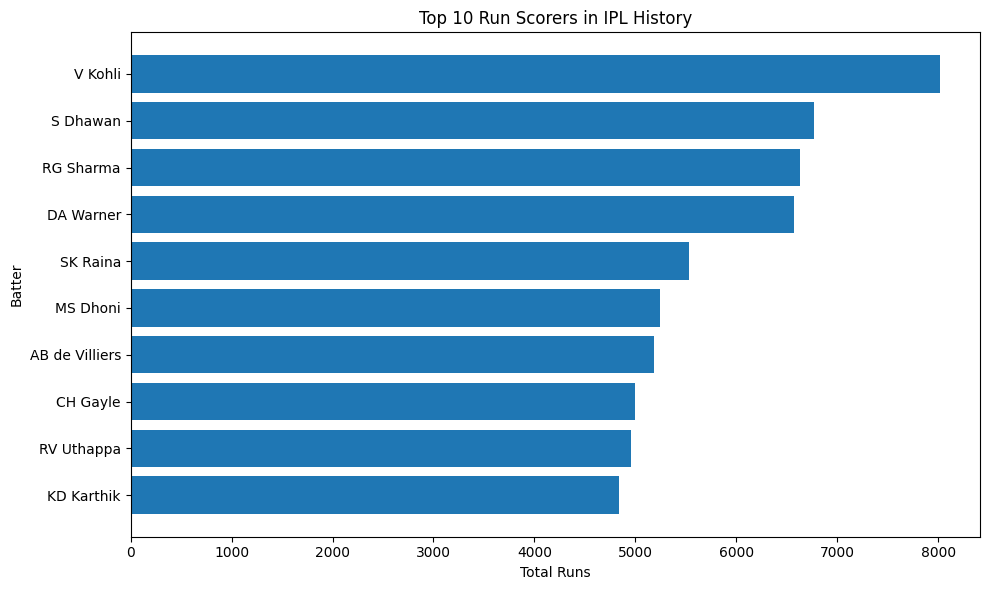

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    top10_scorers.index[::-1],
    top10_scorers.values[::-1]
)

plt.title("Top 10 Run Scorers in IPL History")
plt.xlabel("Total Runs")
plt.ylabel("Batter")

plt.tight_layout()
plt.show()

### 11.2 Top 10 Wicket Takers

This horizontal bar chart compares the 10 bowlers with the highest number of wickets.

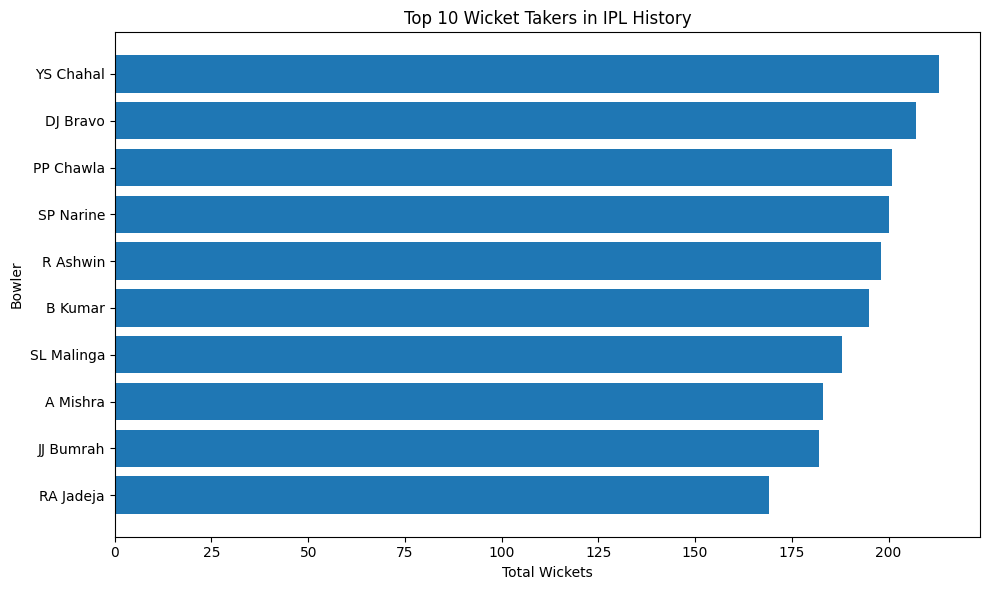

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    top10_wicket_takers.index[::-1],
    top10_wicket_takers.values[::-1]
)

plt.title("Top 10 Wicket Takers in IPL History")
plt.xlabel("Total Wickets")
plt.ylabel("Bowler")

plt.tight_layout()
plt.show()

### 11.3 Top 10 Six Hitters

This horizontal bar chart compares the 10 batters who have hit the most sixes.

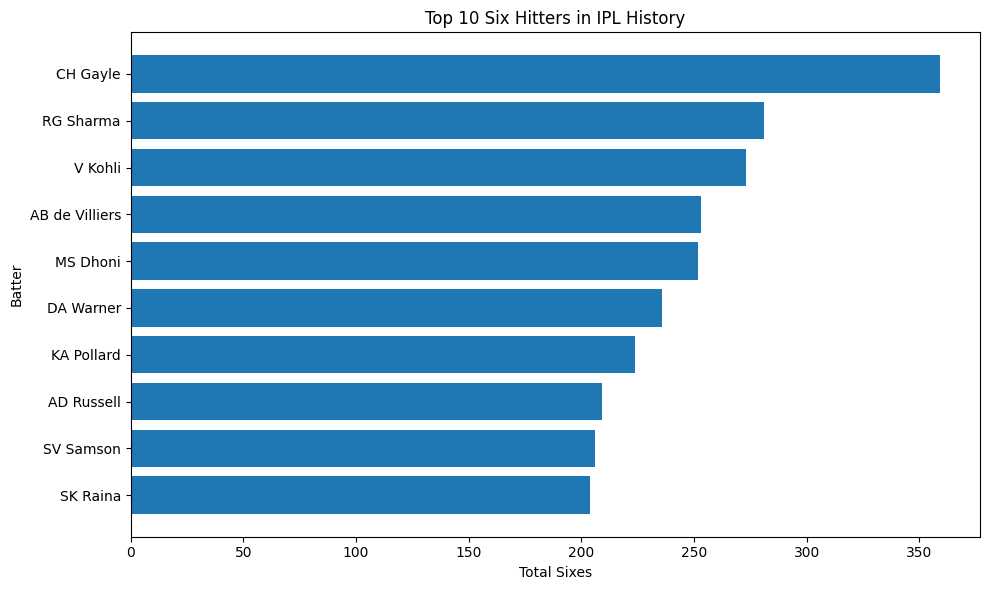

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    top10_sixers.index[::-1],
    top10_sixers.values[::-1]
)

plt.title("Top 10 Six Hitters in IPL History")
plt.xlabel("Total Sixes")
plt.ylabel("Batter")

plt.tight_layout()
plt.show()

### 11.4 Top 10 Strike Rates

This chart compares the top 10 batters with the highest strike rates among players with at least 500 balls faced.

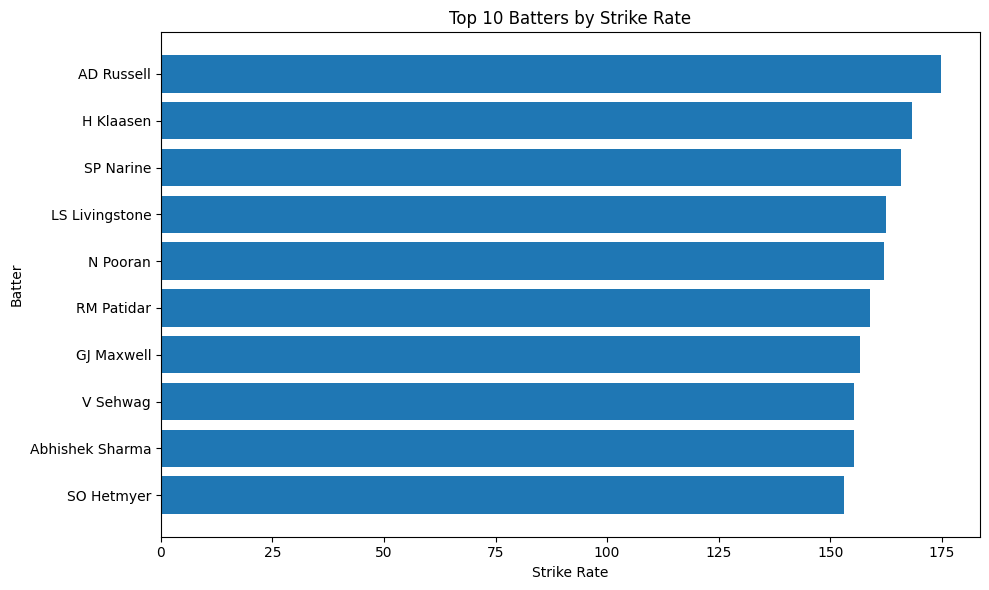

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    top10_strike_rate.index[::-1],
    top10_strike_rate.values[::-1]
)

plt.title("Top 10 Batters by Strike Rate")
plt.xlabel("Strike Rate")
plt.ylabel("Batter")

plt.tight_layout()
plt.show()

### 11.5 Team Win Percentage

This bar chart compares the win percentage of IPL teams based on their total matches and wins.

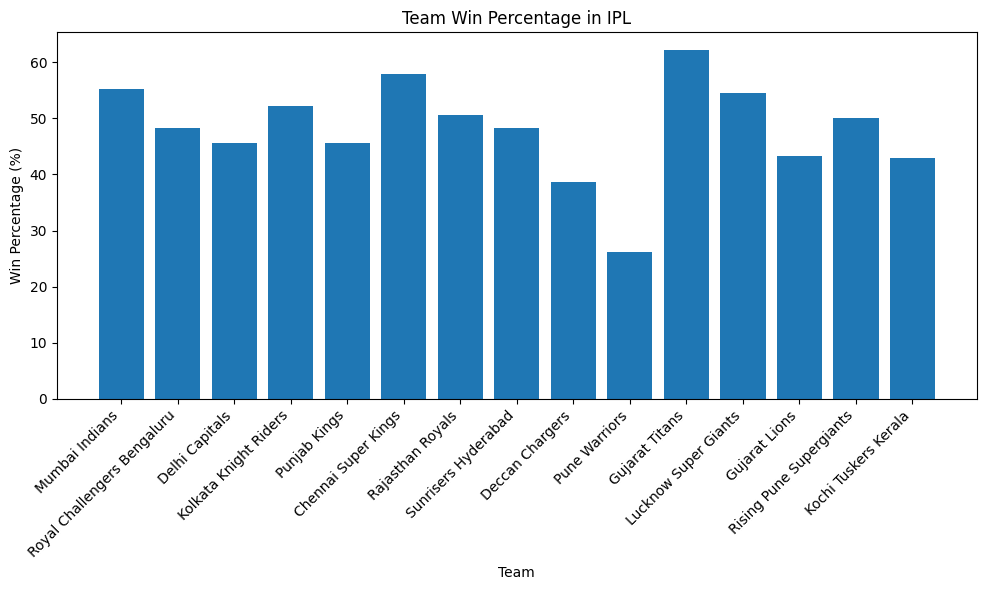

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    team_performance.index,
    team_performance["win_percentage"]
)

plt.title("Team Win Percentage in IPL")
plt.xlabel("Team")
plt.ylabel("Win Percentage (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 11.6 Team Wins

This bar chart compares the total number of matches won by each IPL team.

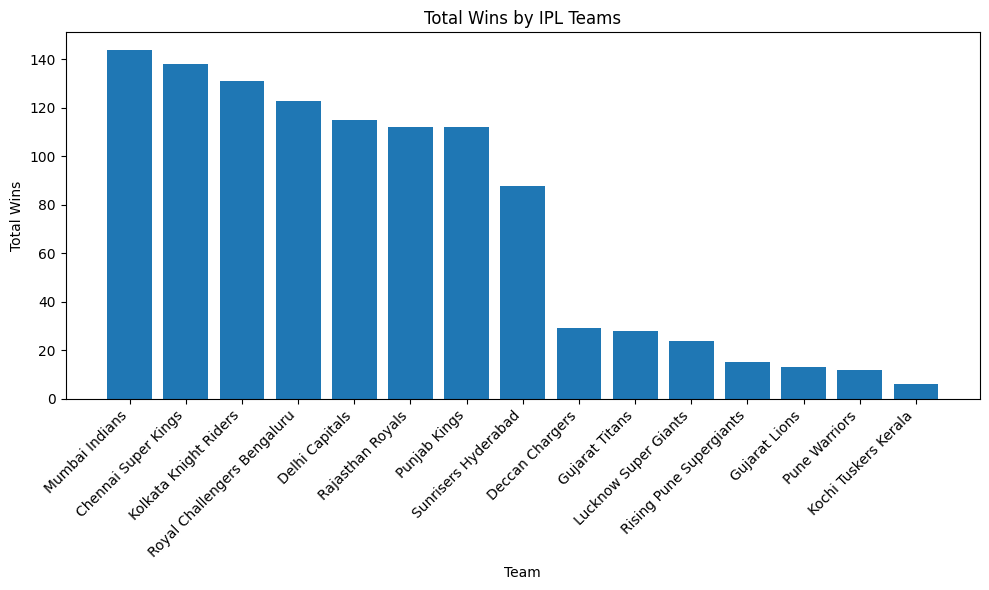

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    total_wins.index,
    total_wins.values
)

plt.title("Total Wins by IPL Teams")
plt.xlabel("Team")
plt.ylabel("Total Wins")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 11.7 Toss Decisions

This bar chart shows how often teams chose to bat or field after winning the toss.

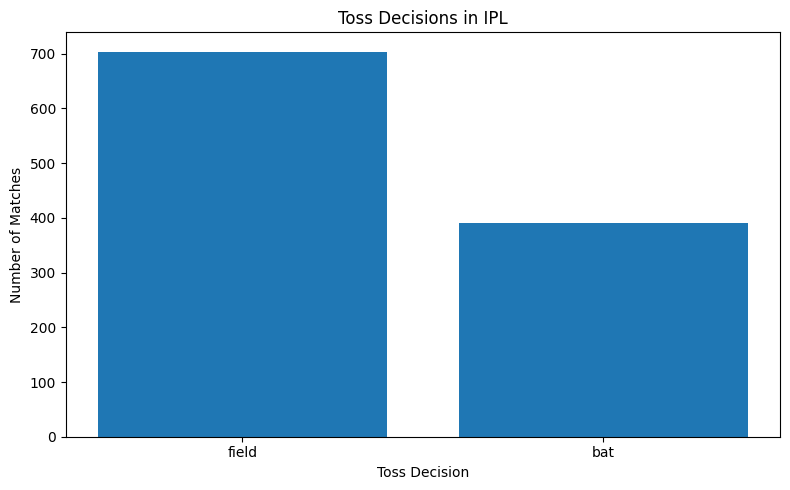

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    toss_decisions.index,
    toss_decisions.values
)

plt.title("Toss Decisions in IPL")
plt.xlabel("Toss Decision")
plt.ylabel("Number of Matches")

plt.tight_layout()
plt.show()

### 11.8 Toss Decision vs Match Outcome

This bar chart compares the percentage of toss winners who also won the match based on their toss decision.

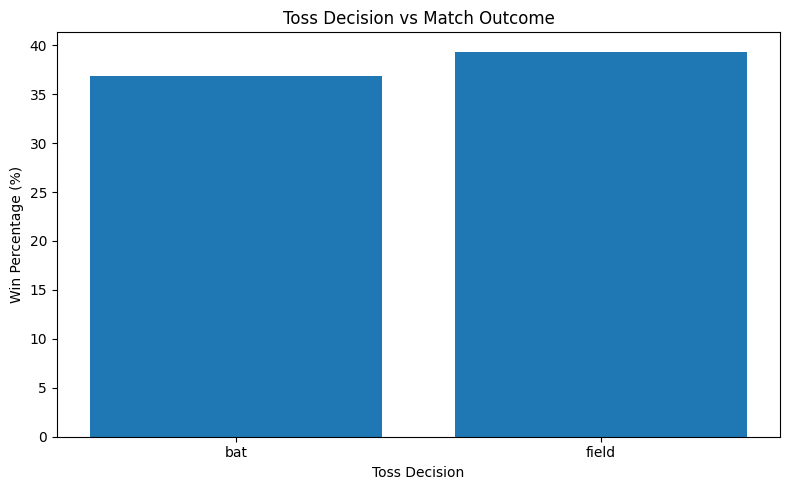

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    toss_outcome.index,
    toss_outcome["win_percentage"]
)

plt.title("Toss Decision vs Match Outcome")
plt.xlabel("Toss Decision")
plt.ylabel("Win Percentage (%)")

plt.tight_layout()
plt.show()

### 11.9 Match Result Type

This bar chart shows the distribution of IPL matches won by runs, wickets , tie or no result

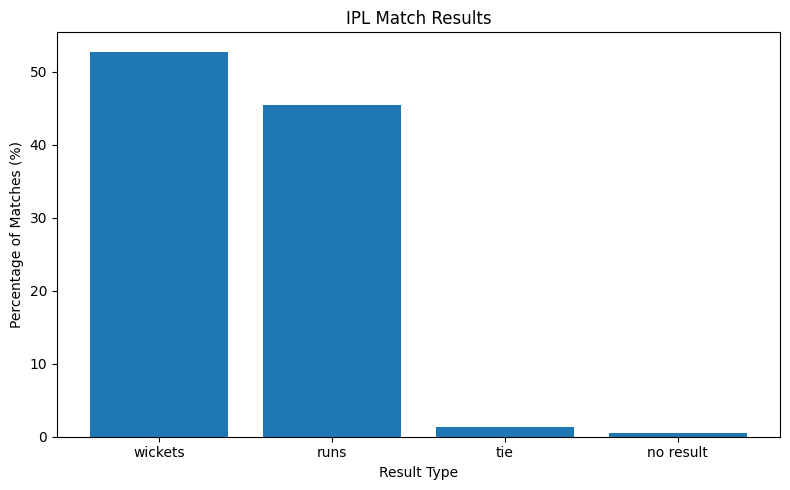

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    result_percentage.index,
    result_percentage.values
)

plt.title("IPL Match Results")
plt.xlabel("Result Type")
plt.ylabel("Percentage of Matches (%)")

plt.tight_layout()
plt.show()

### 11.10 Super Overs by Season

This bar chart shows the number of Super Over matches in each IPL season.

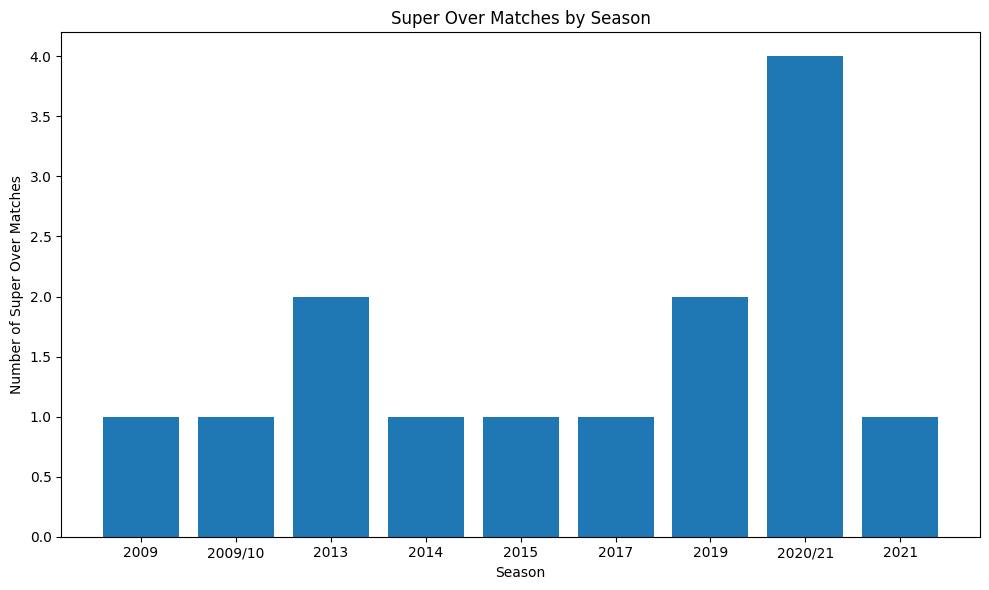

In [25]:
plt.figure(figsize=(10, 6))

plt.bar(
    super_over_by_season.index,
    super_over_by_season.values
)

plt.title("Super Over Matches by Season")
plt.xlabel("Season")
plt.ylabel("Number of Super Over Matches")

plt.tight_layout()
plt.show()

### 11.11 D/L Matches by Season

This bar chart shows the number of matches affected by the D/L method in each IPL season.

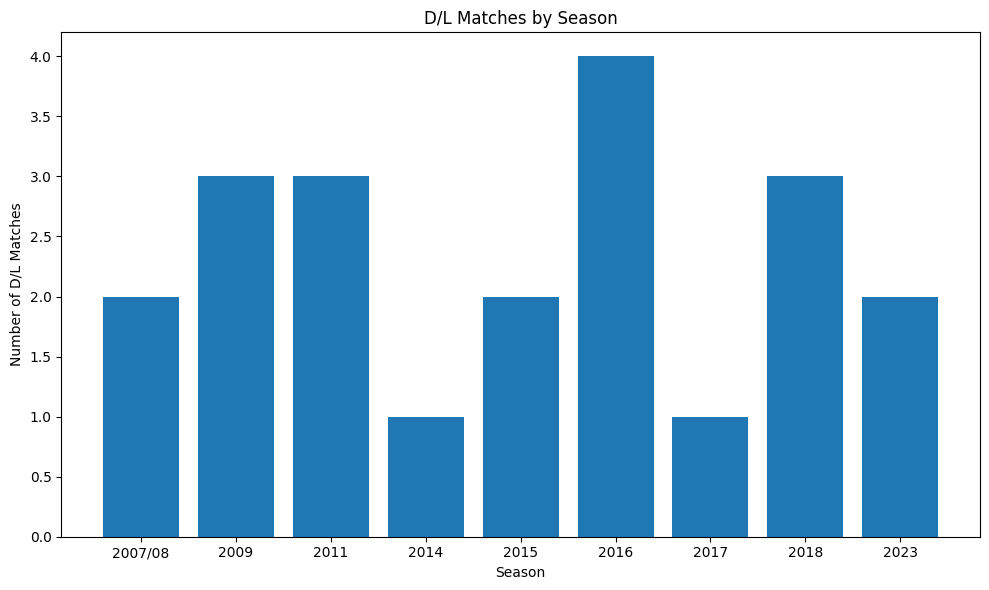

In [29]:
plt.figure(figsize=(10, 6))

plt.bar(
    dl_by_season.index,
    dl_by_season.values
)

plt.title("D/L Matches by Season")
plt.xlabel("Season")
plt.ylabel("Number of D/L Matches")

plt.tight_layout()
plt.show()

### 11.12 Top 10 Venues

This horizontal bar chart shows the 10 venues that hosted the most IPL matches.

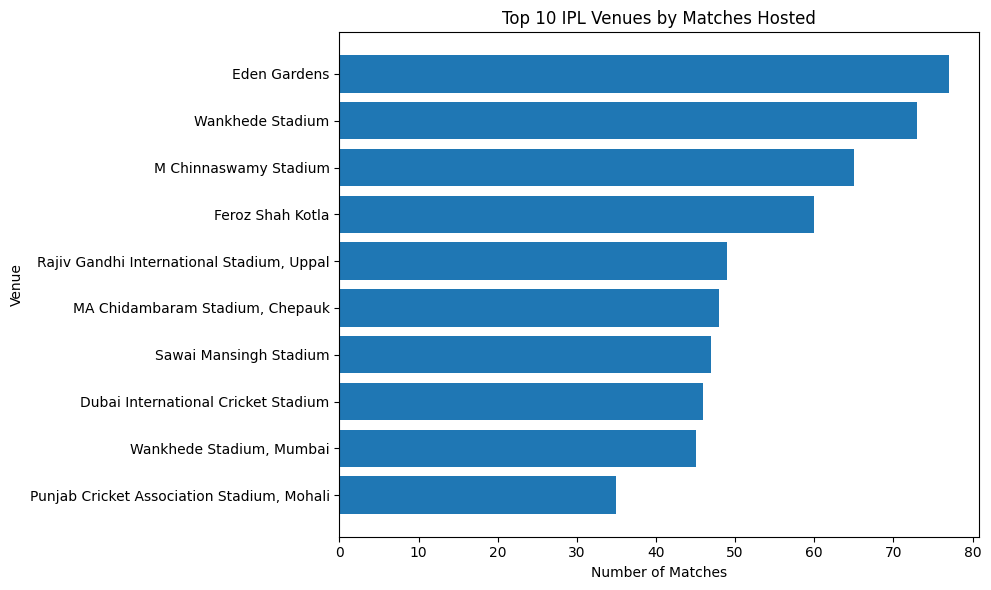

In [32]:
plt.figure(figsize=(10, 6))

plt.barh(
    top10_venues.index[::-1],
    top10_venues.values[::-1]
)

plt.title("Top 10 IPL Venues by Matches Hosted")
plt.xlabel("Number of Matches")
plt.ylabel("Venue")

plt.tight_layout()
plt.show()

### 11.13 Top 10 Cities

This horizontal bar chart shows the 10 cities that hosted the most IPL matches.

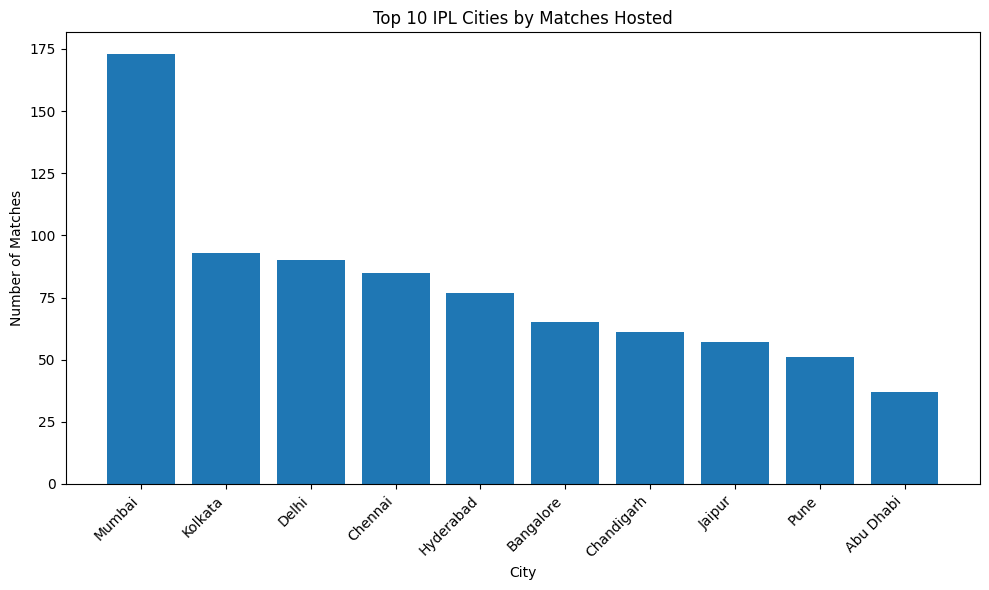

In [40]:
plt.figure(figsize=(10, 6))

plt.bar(
    top10_cities.index,
    top10_cities.values
)

plt.title("Top 10 IPL Cities by Matches Hosted")
plt.xlabel("City")
plt.ylabel("Number of Matches")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 11.14 Average Score by Season

This line chart shows how the average innings score changed across IPL seasons.

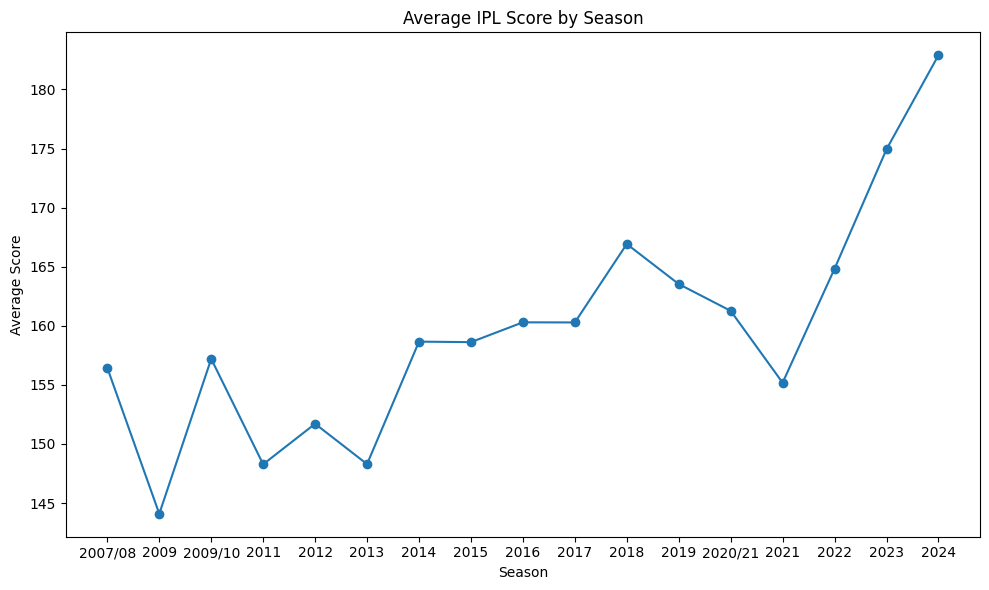

In [49]:
plt.figure(figsize=(10, 6))

plt.plot(
    average_score_by_season.index,
    average_score_by_season.values,
    marker="o"
)

plt.title("Average IPL Score by Season")
plt.xlabel("Season")
plt.ylabel("Average Score")

plt.tight_layout()
plt.show()

### 11.15 Highest Score by Season

This line chart shows the highest innings score recorded in each IPL season.

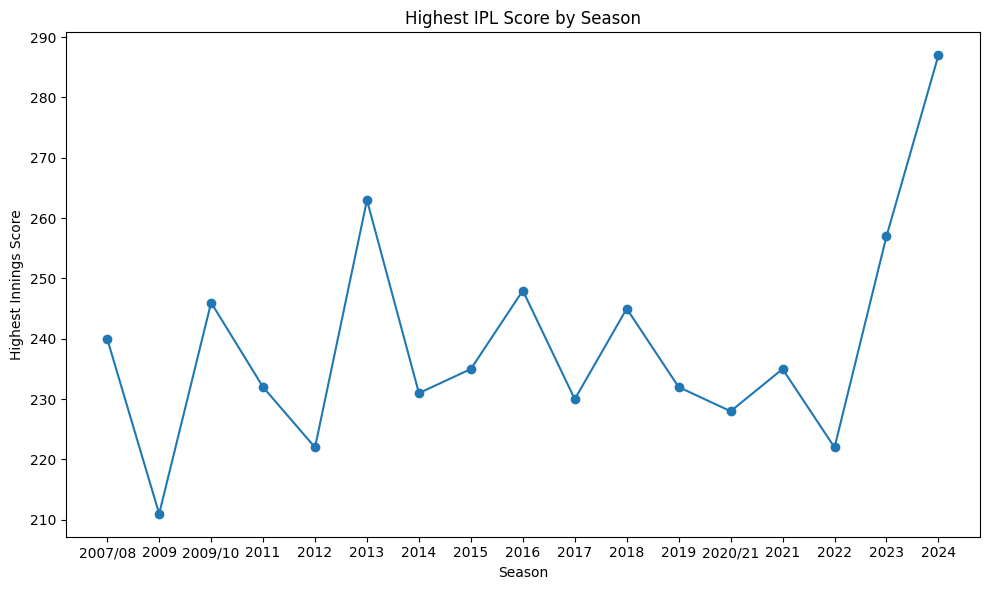

In [54]:
plt.figure(figsize=(10, 6))

plt.plot(
    highest_score_by_season.index,
    highest_score_by_season.values,
    marker="o"
)

plt.title("Highest IPL Score by Season")
plt.xlabel("Season")
plt.ylabel("Highest Innings Score")

plt.tight_layout()
plt.show()

### 11.16 Teams with 200+ Innings

This bar chart compares the number of 200+ innings recorded by each team.

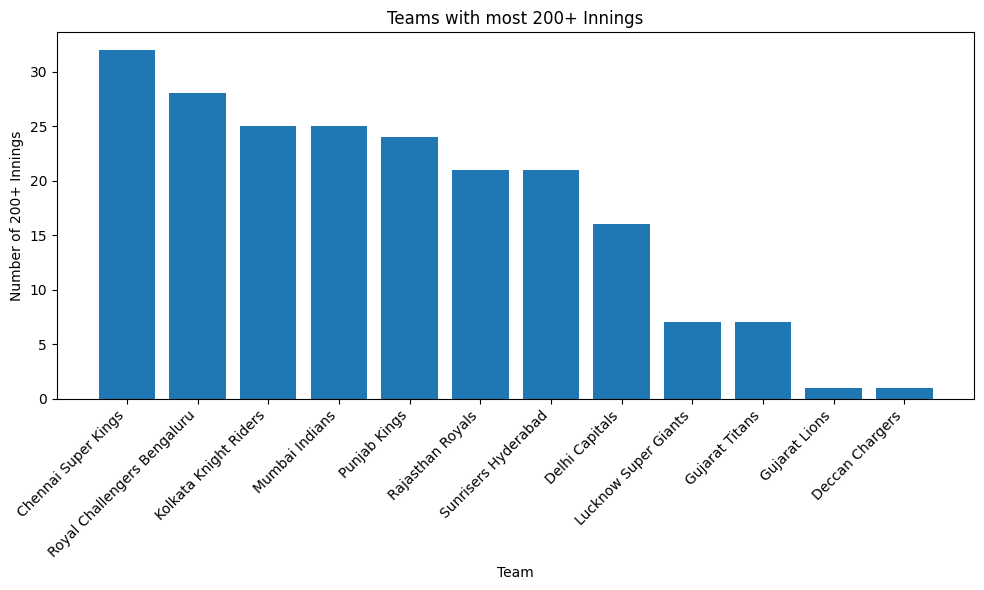

In [58]:
plt.figure(figsize=(10, 6))

plt.bar(
    teams_200_plus.index,
    teams_200_plus.values
)

plt.title("Teams with most 200+ Innings")
plt.xlabel("Team")
plt.ylabel("Number of 200+ Innings")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()